# Methode def

In [122]:
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from circuit_generation import *
from tree_class import *
from best_mps_ordering import local_greedy_swap, greedy_weighted_linear_arrangement, plot_graph_comparisons
import pandas as pd
import networkx as nx

def get_binary_tree_adj(nb_node):
    h = np.log2(nb_node)
    G = nx.generators.classic.balanced_tree(2,int(h))
    nodes_to_remove = sorted(list(G.nodes))[nb_node:]  # Keep first n nodes
    G.remove_nodes_from(nodes_to_remove)
    nx.draw(G)
    return nx.adjacency_matrix(G).toarray()

def test_tree_mps(circ,n_qb = 10,max_bond=None,return_memory=False, plot = False):
    G, mst, adj = plot_connectivity_and_max_mst(circ, return_adjacency_matrix=True)

    # non reordered mps-------------------------------
    mps = qtn.CircuitMPS(n_qb,max_bond=max_bond)
    for gate in circ.gates:
        mps.apply_gate(gate)
    mps_net = mps.psi
    
    # Tree -------------------------------------------

    tree,trad_dic = tree_from_matrix(adj,0,max_bond=max_bond)
    tree = replicate_circ(circ,tree,trad_dic)

    reindex_dic = {'k'+str(k): 'out'+ str(v) for k, v in trad_dic.items()}
    circ_net_reindexed = circ.psi.reindex_(reindex_dic).H
    tree_net = tree.network

    #Binary Tree
    btree,trad_dic2 = tree_from_matrix(get_binary_tree_adj(n_qb),0,max_bond=max_bond)
    btree = replicate_circ(circ,btree,trad_dic2)

    reindex_dic2 = {'k'+str(k): 'out'+ str(v) for k, v in trad_dic2.items()}
    circ_net_reindexed2 = circ.psi.reindex_(reindex_dic2).H
    tree_net2 = btree.network


    # Compute fidelity to original circuit
    circ_net = circ.psi.H

    fnet = circ_net_reindexed & tree_net
    fnet2 = circ_net_reindexed2 & tree_net2
    fnetMPS = circ_net & mps_net
    
    fidelity_tree = np.abs(fnet.contract())
    fidelity_mps = np.abs(fnetMPS.contract())
    fidelity_btree = np.abs(fnet2.contract())

    if return_memory:
        mem_tree = sum(t.size for t in tree.network)
        mem_mps = sum(t.size for t in mps.psi)
        mem_btree = sum(t.size for t in btree.network)

        return(fidelity_tree,fidelity_mps,fidelity_btree, mem_tree,mem_mps, mem_btree)
    
    return(fidelity_tree, fidelity_mps, fidelity_btree)

def replicate_circ(circ,tree,trad_dic):
    
    for gate in circ.gates:
        if gate.label == 'RX':
            param = gate.params[0]
            qubit = trad_dic[gate.qubits[0]]
            tree.apply_1qb_gate(i = qubit,gate_array=gate.build_array())

        if gate.label == 'CNOT':
            qubit_1 = trad_dic[gate.qubits[0]]
            qubit_2 = trad_dic[gate.qubits[1]]
            tree.apply_2qb_gate(i = qubit_1,j = qubit_2,gate_array=gate.build_array().reshape(2,2,2,2))
    return tree



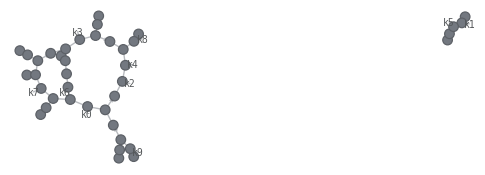

In [113]:
circ = generate_random_circuit(num_qubits=10,num_gates=10)
circ.psi.draw()

# simulations

In [134]:
chi_range = range(1,20,3) 
N_gate_range = range(10,220,50)
nb_moy = 5
N_qubits = 10
print(list(chi_range))
print(list(N_gate_range))

[1, 4, 7, 10, 13, 16, 19]
[10, 60, 110, 160, 210]


100%|██████████| 5/5 [19:40<00:00, 236.02s/it]


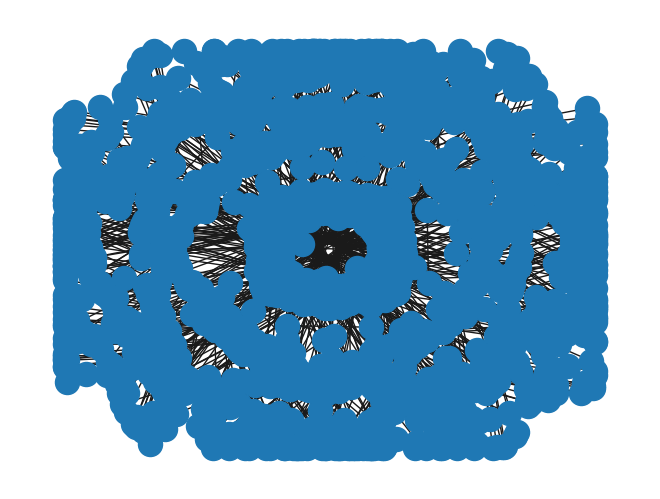

In [135]:
tree_fidelity_values = []
mps_fidelity_values = []
mps_ordered_fidelity_values = []
diff_values = []
delta_mps = []

results = []
chi_tree_moy_dic = {}
chi_mps_moy_dic = {}
chi_btree_moy_dic = {}

mem_tree_moy_dic = {}
mem_mps_moy_dic = {}
mem_btree_moy_dic = {}

for N in tqdm(N_gate_range):
    df_results = pd.DataFrame(results)
    df_results.to_csv('results_df.csv')

    for chi in chi_range:
        chi_mps_moy_dic[chi] = []
        chi_btree_moy_dic[chi] = []
        chi_tree_moy_dic[chi] = []
        mem_tree_moy_dic[chi] = []
        mem_mps_moy_dic[chi] = []
        mem_btree_moy_dic[chi] = []

    for i in range(nb_moy):
        circ = generate_random_circuit(num_qubits=N_qubits,num_gates=N,plot=False)

        for chi in chi_range:
            tree_fidelity,mps_fidelity,btree_fidelity,mem_tree,mem_mps,mem_btree = test_tree_mps(circ = circ,n_qb=N_qubits,max_bond=chi,return_memory=True)
            chi_tree_moy_dic[chi].append(tree_fidelity)
            chi_mps_moy_dic[chi].append(mps_fidelity)
            chi_btree_moy_dic[chi].append(btree_fidelity)
            mem_tree_moy_dic[chi].append(mem_tree)
            mem_mps_moy_dic[chi].append(mem_mps)
            mem_btree_moy_dic[chi].append(mem_btree)
    
    for chi in chi_range:
        results.append({
            'N': N,
            'chi': chi,
            'f_tree': np.mean(chi_tree_moy_dic[chi]),
            'f_std_tree':np.std(chi_tree_moy_dic[chi]),
            'f_mps': np.mean(chi_mps_moy_dic[chi]),
            'f_std_mps':np.std(chi_mps_moy_dic[chi]),
            'f_btree': np.mean(chi_btree_moy_dic[chi]),
            'f_std_btree':np.std(chi_btree_moy_dic[chi]),
            'mem_tree': np.mean(mem_tree_moy_dic[chi]),
            'mem_std_tree':np.std(mem_tree_moy_dic[chi]),
            'mem_mps': np.mean(mem_mps_moy_dic[chi]),
            'mem_std_mps':np.std(mem_mps_moy_dic[chi]),
            'mem_btree': np.mean(mem_btree_moy_dic[chi]),
            'mem_std_btree':np.std(mem_btree_moy_dic[chi]),
            })

df_results = pd.DataFrame(results)
df_results.to_csv('results_bt_df.csv')

In [129]:
df_results = pd.DataFrame(results)

# Binary tree

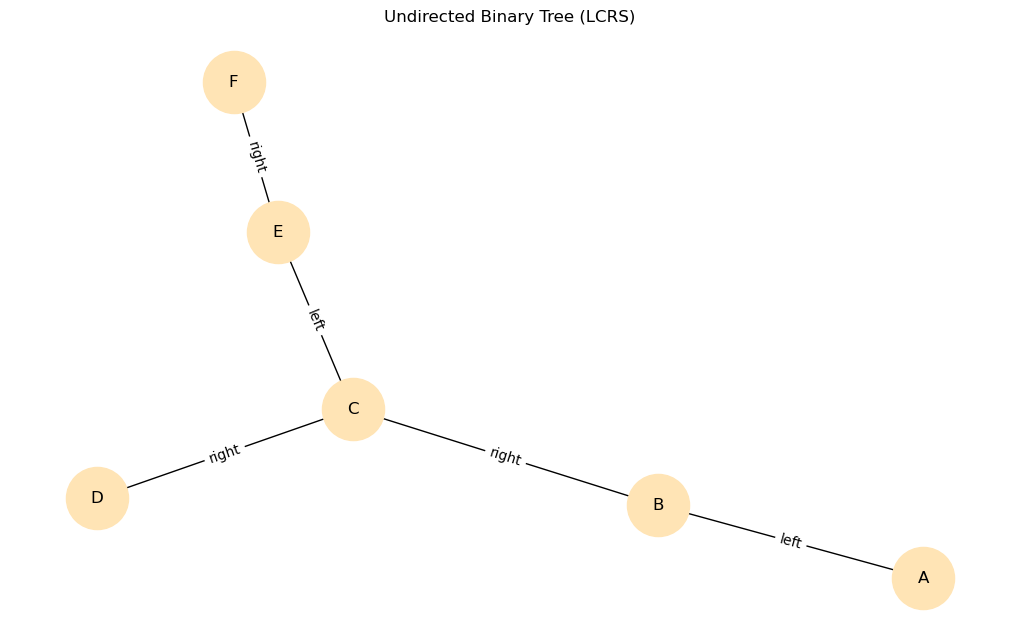

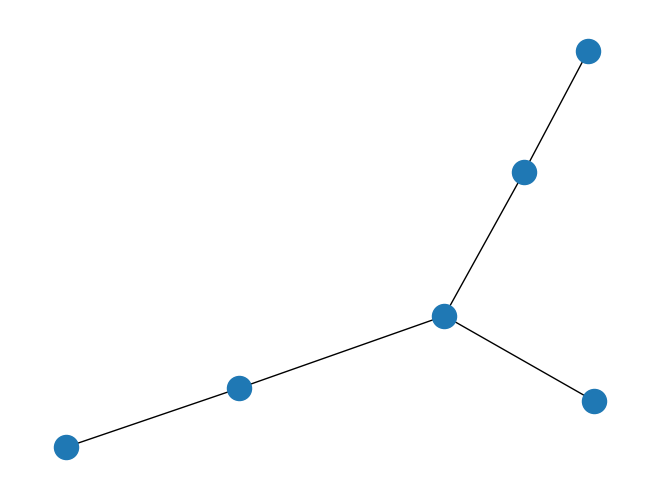

In [87]:
import networkx as nx
import matplotlib.pyplot as plt

# Step 1: Create the original undirected non-binary tree
G = nx.Graph()
G.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("A", "D"),
    ("C", "E"),
    ("C", "F")
])

# Step 2: Infer parent/child relationships from undirected graph
def build_tree_structure(undirected_graph, root):
    parent_map = {}
    children_map = {}

    def dfs(node, parent=None):
        parent_map[node] = parent
        children_map[node] = []
        for neighbor in undirected_graph.neighbors(node):
            if neighbor != parent:
                children_map[node].append(neighbor)
                dfs(neighbor, node)

    dfs(root)
    return parent_map, children_map

parent_map, children_map = build_tree_structure(G, "A")

# Step 3: Convert to LCRS but keep it undirected
def lcrs_to_undirected_binary(children_map, root):
    binary_tree = nx.Graph()

    def convert(node):
        children = children_map.get(node, [])
        if not children:
            return

        # First child becomes "left"
        left = children[0]
        binary_tree.add_edge(node, left, relation="left")
        convert(left)

        # Remaining children chained as "right" siblings
        current = left
        for sibling in children[1:]:
            binary_tree.add_edge(current, sibling, relation="right")
            convert(sibling)
            current = sibling

    binary_tree.add_node(root)
    convert(root)
    return binary_tree

binary_tree = lcrs_to_undirected_binary(children_map, "A")

# Step 4: Draw the undirected binary tree
def draw_binary_tree(G):
    pos = nx.spring_layout(G, seed=42)
    edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
    nx.draw(G, pos, with_labels=True, node_color="#ffe4b5", node_size=2000)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.figure(figsize=(10, 6))
draw_binary_tree(binary_tree)
plt.title("Undirected Binary Tree (LCRS)")
plt.show()
nx.draw(binary_tree)

# plot

In [ ]:
df_results.to_csv('results_bt_df.csv')

In [116]:
pd.read_csv('results_bt_df.csv')  

,Unnamed: 0,N,chi,f_tree,f_std_tree,f_mps,f_std_mps,f_btree,f_std_btree,mem_tree,mem_std_tree,mem_mps,mem_std_mps,mem_btree,mem_std_btree
0,0,10,1,0.715632,1.476525e-01,0.715632,1.476525e-01,0.715632,1.476525e-01,20.0,0.000000,20.0,0.000000,20.0,0.0
1,1,10,3,0.997457,6.133373e-03,0.988104,1.956310e-02,0.899610,1.618641e-01,204.0,141.706739,75.8,34.703890,152.0,0.0
2,2,10,5,1.000000,2.391236e-15,0.999029,2.577474e-03,0.996160,1.142756e-02,417.8,224.273850,103.8,65.497786,366.0,0.0
3,3,10,7,1.000000,1.760325e-15,0.999895,3.034433e-04,0.998078,3.965890e-03,617.8,164.762739,114.8,81.825179,638.0,0.0
4,4,10,9,1.000000,1.867024e-15,1.000000,1.099065e-15,1.000000,2.845274e-08,810.6,114.378494,117.8,88.609029,884.0,0.0
5,5,20,1,0.331279,1.140722e-01,0.331279,1.140722e-01,0.331279,1.140722e-01,20.0,0.000000,20.0,0.000000,20.0,0.0
6,6,20,3,0.868434,1.308738e-01,0.772846,1.796573e-01,0.661933,1.542781e-01,251.2,128.580558,114.6,9.718024,152.0,0.0
7,7,20,5,0.952686,7.649093e-02,0.922078,8.547085e-02,0.876428,1.349276e-01,552.2,294.345987,246.4,46.910980,366.0,0.0
8,8,20,7,0.986203,2.309556e-02,0.972717,3.928066e-02,0.929617,8.227181e-02,723.4,230.229538,370.2,110.081606,638.0,0.0
9,9,20,9,0.996054,8.425542e-03,0.993377,1.401223e-02,0.965171,5.456455e-02,873.4,171.347717,443.8,205.244147,884.0,0.0


In [80]:
df_results.tail()

,N,chi,f_tree,f_std_tree,f_mps,f_std_mps,f_btree,f_std_btree,mem_tree,mem_std_tree,mem_mps,mem_std_mps,mem_btree,mem_std_btree
31,40,5,0.407079,0.188493,0.340695,0.128998,0.407079,0.188493,366.8,68.586879,293.4,21.091230,366.8,68.586879
32,40,6,0.481699,0.175291,0.421253,0.136475,0.481699,0.175291,474.8,92.659376,405.6,24.228908,474.8,92.659376
33,40,7,0.574200,0.188211,0.489957,0.130151,0.574200,0.188211,597.2,125.067022,515.4,36.211048,597.2,125.067022
34,40,8,0.674363,0.168196,0.588203,0.145545,0.674363,0.168196,734.0,165.739555,627.6,70.204273,734.0,165.739555
35,40,9,0.725236,0.143694,0.640473,0.137661,0.725236,0.143694,810.8,140.698827,741.8,60.308872,810.8,140.698827


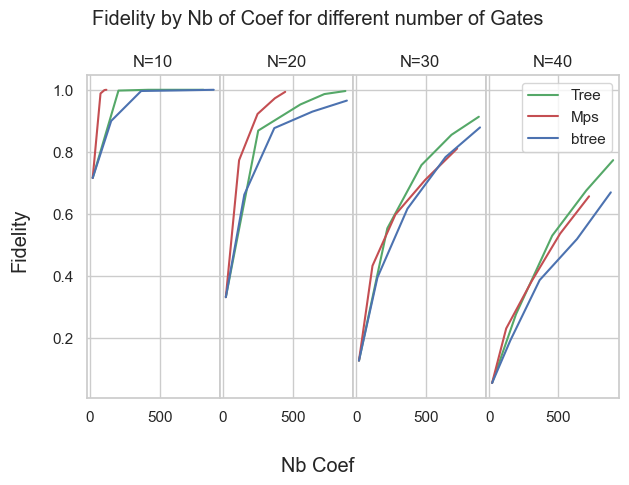

In [130]:
df_results = pd.read_csv('results_bt_df.csv')

N = df_results['N']
CHI = df_results['chi']
RES_tree = df_results['f_tree']
RES_mps = df_results['f_mps']
RES_btree = df_results['f_btree']
MEM_tree = df_results['mem_tree']
MEM_mps = df_results['mem_mps']
MEM_btree = df_results['mem_btree']

chi_range = range(int(np.min(CHI)),int(np.max(CHI))+1,int(CHI[1]-CHI[0]))
N_gate_range = range(int(np.min(N)),int(np.max(N))+1,int(N[len(chi_range)]-N[0]))

# RES = np.array(RES).reshape(len(N),len(CHI))
N = np.array(N).reshape(len(N_gate_range),len(chi_range))
CHI = np.array(CHI).reshape(len(N_gate_range),len(chi_range))
RES_tree = np.array(RES_tree).reshape(len(N_gate_range),len(chi_range))
RES_mps = np.array(RES_mps).reshape(len(N_gate_range),len(chi_range))
RES_btree = np.array(RES_btree).reshape(len(N_gate_range),len(chi_range))
MEM_tree = np.array(MEM_tree).reshape(len(N_gate_range),len(chi_range))
MEM_mps = np.array(MEM_mps).reshape(len(N_gate_range),len(chi_range))
MEM_btree = np.array(MEM_btree).reshape(len(N_gate_range),len(chi_range))

# plt.plot(MEM_tree[i],RES_tree[i],color='g')
# plt.plot(MEM_mps[i],RES_mps[i],color='r')
# plt.show()


fig = plt.figure()
gs = fig.add_gridspec(1, len(N.T[0]), hspace=0, wspace=0)
axes = gs.subplots(sharex='col', sharey='row')
fig.suptitle('Fidelity by Nb of Coef for different number of Gates')
fig.supxlabel('Nb Coef')
fig.supylabel('Fidelity')

# fig, axes = plt.subplots(1,9,sharey=True)

for i in range(len(N.T[0])):
    axes[i].plot(MEM_tree[i],RES_tree[i],color = 'g',label = 'Tree')
    axes[i].plot(MEM_mps[i],RES_mps[i],color = 'r',label = 'Mps')
    axes[i].plot(MEM_btree[i],RES_btree[i],color = 'b',label = 'btree')
    axes[i].set_title('N='+str(int(N.T[0][i])))

axes[-1].legend()
# for ax in axes.flat:
#     ax.set(xlabel='Nb Coef', ylabel='Fidelity')
for ax in axes.flat:
    ax.label_outer()

plt.tight_layout()

plt.show()

## tidying

In [117]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tidy dataframe creation (as before)
df = df_results

methods = ['tree', 'mps', 'btree']
tidy_df = pd.DataFrame()

for method in methods:
    method_df = pd.DataFrame({
        'N': df['N'],
        'chi': df['chi'],
        'method': method.upper(),
        'fidelity': df[f'f_{method}'] if f'f_{method}' in df else df[f'fidelity_{method}'],
        'fidelity_std': df[f'f_std_{method}'],
        'memory': df[f'mem_{method}'],
        'memory_std': df[f'mem_std_{method}']
    })
    tidy_df = pd.concat([tidy_df, method_df], ignore_index=True)

## fidelity on mem

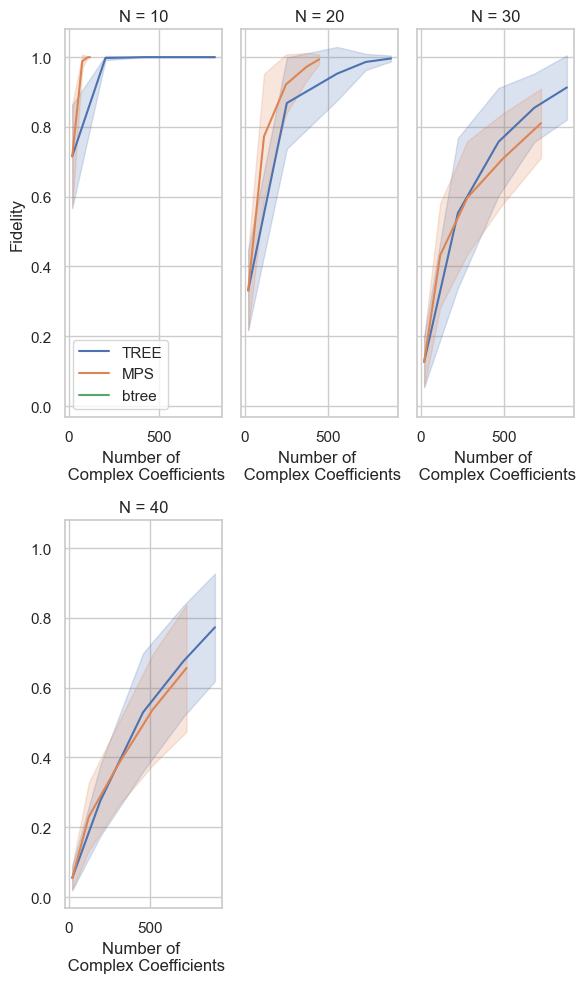

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="notebook")

unique_Ns = sorted(tidy_df['N'].unique())
# ncols = 2
# nrows = (len(unique_Ns) + 1) // ncols
ncols = len(unique_Ns)//2 +1
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2 * ncols, 5 * nrows), sharex=False, sharey=True)
axes = axes.flatten()

palette = {'TREE': 'C0', 'MPS': 'C1', 'btree': 'C2'}

for i, N_val in enumerate(unique_Ns):
    ax = axes[i]
    subset = tidy_df[tidy_df['N'] == N_val]

    for method in ['TREE', 'MPS', 'btree']:
        sub = subset[subset['method'] == method]
        
        # Sort by memory to avoid jagged lines
        sub = sub.sort_values(by='memory')
        
        # Plot line
        ax.plot(sub['memory'], sub['fidelity'], label=method, color=palette[method])
        
        # Plot error band
        ax.fill_between(
            sub['memory'],
            sub['fidelity'] - sub['fidelity_std'],
            sub['fidelity'] + sub['fidelity_std'],
            alpha=0.2,
            color=palette[method]
        )

    ax.set_title(f'N = {N_val}')
    ax.set_xlabel('Number of \n Complex Coefficients')
    # ax.set_ylabel('Fidelity')
    # ax.legend()
    ax.grid(True)

axes[0].set_ylabel('Fidelity')
axes[0].legend()

# Clean up unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## mem for min f on N

In [120]:
threshold = 0.95

# Conservative fidelity: subtract std to ensure it's safely above the threshold
conservative_df = tidy_df[tidy_df['fidelity'] - tidy_df['fidelity_std'] > threshold]

# For each N and method, get the row with min memory
min_mem_with_uncertainty = (
    conservative_df
    .sort_values('memory')
    .groupby(['N', 'method'], as_index=False)
    .first()  # First row after sorting by memory == minimum memory
)

# Rename for clarity
min_mem_with_uncertainty = min_mem_with_uncertainty.rename(columns={
    'memory': 'min_mem',
    'memory_std': 'min_mem_std'
})


sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))

methods = min_mem_with_uncertainty['method'].unique()
palette = {'TREE': 'C0', 'MPS': 'C1', 'btree': 'C2'}

for method in methods:
    sub = min_mem_with_uncertainty[min_mem_with_uncertainty['method'] == method]
    
    # Sort for line plotting
    sub = sub.sort_values(by='N')
    
    # Plot line
    plt.plot(sub['N'], sub['min_mem'], label=method, marker='o', color=palette[method])
    
    # Plot error band
    plt.fill_between(
        sub['N'],
        sub['min_mem'] - sub['min_mem_std'],
        sub['min_mem'] + sub['min_mem_std'],
        alpha=0.2,
        color=palette[method]
    )

plt.title(f"Minimum Number of Complex Coef. to reach Fidelity > {threshold}")
plt.xlabel("Number of gates")
plt.ylabel("Minimum Number of Complex Coef.")
plt.legend(title="Method")
plt.tight_layout()
plt.show()

KeyError: 'BTREE'

<Figure size 800x600 with 0 Axes>